In [23]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {OUT_DIR}")


Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking
Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# Separation Experiment: regular vs separated tracking

This notebook compares two ways of tracking a mixed population of slow/static and mobile particles on the same simulated movie.

1. **Regular pipeline:** localize and track all detections together.
2. **Separated pipeline:** first identify slow/static trajectories, remove their detections from the peak list, track the remaining mobile peaks, then add the static trajectories back before final GT assignment.

The old exploratory branch is preserved at the bottom as notes, but the executable path below is now one coherent flow using one seeded simulation.


In [24]:
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from Helpers.helpersGeneration import animate_video, save_video_as_gif, show_trajectories
from Helpers.helpersSimulation import Simulator
from Helpers.helpersTracking import (
    DistanceTerm,
    IntensityTerm,
    PeakToPeak,
    extract_peaks,
    remove_static_peaks,
    track_from_peaks,
)
from Helpers.helpersAssignment import (
    LengthDifferenceTerm,
    MeanPositionDistanceTerm,
    StartFrameDifferenceTerm,
    TrajToTraj,
    assign_trajectories,
)
from Helpers.helpersPlotting import linear_trajectories_visualizer
from Helpers.helpersStatistics import coverage_and_fragments, hota_only


## Experiment design

The comparison must use exactly the same simulated movie for both strategies. The random seed is fixed, and all aliases (`frames_reg`, `frames_sep`, etc.) point back to the same generated data so that differences come only from the tracking strategy.


In [25]:
SEED = 42
SAVE_GIFS = False

D_list = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 10,
    "nframes": 20,
    "nposframe": 5,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 800,
    "intensity_std": 100,
}

image_config = {
    "particle_intensity": [800, 100],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

REGULAR_TRACKING_KWARGS = {
    "mode": "localization",
    "detection_threshold": 400,
    "max_distance": 10,
    "min_length": 5,
}

STATIC_TRACKING_KWARGS = {
    "mode": "localization",
    "detection_threshold": 400,
    "max_distance": 2,
    "min_length": 5,
}

PEAK_EXTRACTION_KWARGS = {
    "mode": "localization",
    "detection_threshold": None,
    "verbose_loc": False,
    "visualization_loc": False,
}

MOBILE_TRACKING_KWARGS = {
    "max_distance": 10,
    "min_length": 5,
    "algo_peak2peak": "hungarian",
    "cost_func_peak2peak": None,
    "verbose_assignment": False,
}

REMOVE_STATIC_TOLERANCE = 5.0


In [26]:
peak2peak_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=0.5, norm=image_config["output_size"] / 10),
        "intensity": IntensityTerm(
            weight=0.5,
            norm=image_config["particle_intensity"][0] + image_config["particle_intensity"][1],
        ),
    }
)

traj_cost = TrajToTraj(
    terms={
        "position": MeanPositionDistanceTerm(weight=0.8, norm=1.0),
        "length": LengthDifferenceTerm(weight=0.1, norm=10),
        "start_frame": StartFrameDifferenceTerm(weight=0.1, norm=5),
    }
)


In [27]:
sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=SEED,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR
trajectories_GT = sim.trajectories_GT
trajectories_FR = sim.trajectories_FR
video = sim.video

# Backward-compatible aliases used by the comparison cells.
sim_reg = sim_sep = sim
frames_reg = frames_sep = frames
trajs_GT_reg = trajs_GT_sep = trajectories_GT
video_reg = video_sep = video

print(f"Simulated {simulation_config['nparticles']} particles for {simulation_config['nframes']} frames with seed={SEED}.")


Simulated 10 particles for 20 frames with seed=42.


In [28]:
animate_video(video, interval=100, vmin=0, vmax=1000)


In [29]:
if SAVE_GIFS:
    save_video_as_gif(video, filename="separated.gif", fps=10)


In [30]:
def animate_video_with_peaks(
    video,
    peaks,
    interval=100,
    cmap="gray",
    vmin=0,
    vmax=1000,
    marker_size=55,
):
    """
    Animate a video and overlay detections as red crosses.

    peaks[frame] is expected to contain detections whose first element is
    the position in image coordinates as (row, col).
    """
    fig, ax = plt.subplots(figsize=(5, 5))

    if vmin is None:
        vmin = video.min()
    if vmax is None:
        vmax = video.max()

    im = ax.imshow(video[0], cmap=cmap, vmin=vmin, vmax=vmax, animated=True)
    scat = ax.scatter(
        [],
        [],
        s=marker_size,
        c="red",
        marker="x",
        linewidths=1.5,
        animated=True,
    )
    title = ax.set_title("Frame 0")
    ax.axis("off")

    def update(frame):
        im.set_array(video[frame])

        peak_positions = np.array([peak[0] for peak in peaks[frame]], dtype=float)
        if len(peak_positions) > 0:
            rows = peak_positions[:, 0]
            cols = peak_positions[:, 1]
            scat.set_offsets(np.c_[cols, rows])
        else:
            scat.set_offsets(np.empty((0, 2)))

        title.set_text(f"Frame {frame}")
        return [im, scat, title]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(video),
        interval=interval,
        blit=True,
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())


## 1. Regular tracking

The regular strategy tracks all localized detections together with a standard maximum linking distance.


Regular pipeline found 16 trajectories.


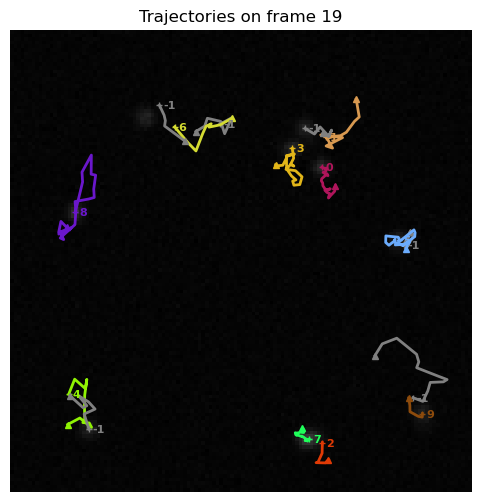

In [31]:
loc_results_reg = sim.track(
    **REGULAR_TRACKING_KWARGS,
    cost_func_peak2peak=peak2peak_cost,
    cost_func_traj2traj=traj_cost,
)

trajs_loc_reg, cost_peak2peak_reg, assignment_output_reg, cost_traj2traj_reg = loc_results_reg

print(f"Regular pipeline found {len(trajs_loc_reg)} trajectories.")
show_trajectories(
    frames_reg,
    trajs_loc_reg,
    frame_id=simulation_config["nframes"] - 1,
    show_id=True,
)


## 2. Separated tracking

The separated strategy keeps the same movie but changes the order of operations:

1. Track only static/slow particles with a strict linking radius.
2. Extract all localized peaks.
3. Remove the peaks belonging to the static trajectories.
4. Track the remaining mobile peaks.
5. Add static and mobile trajectories together, then assign the combined result to GT.


Separated static pass found 6 static/slow trajectories.


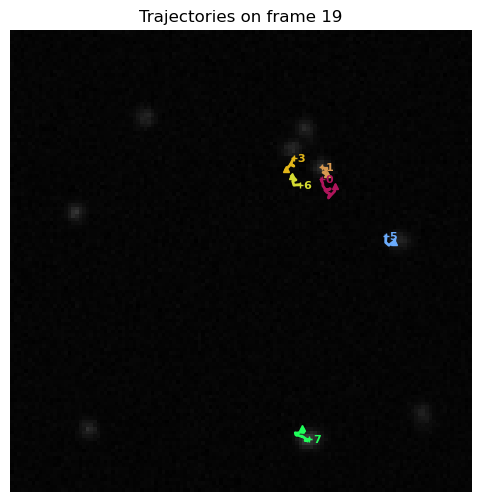

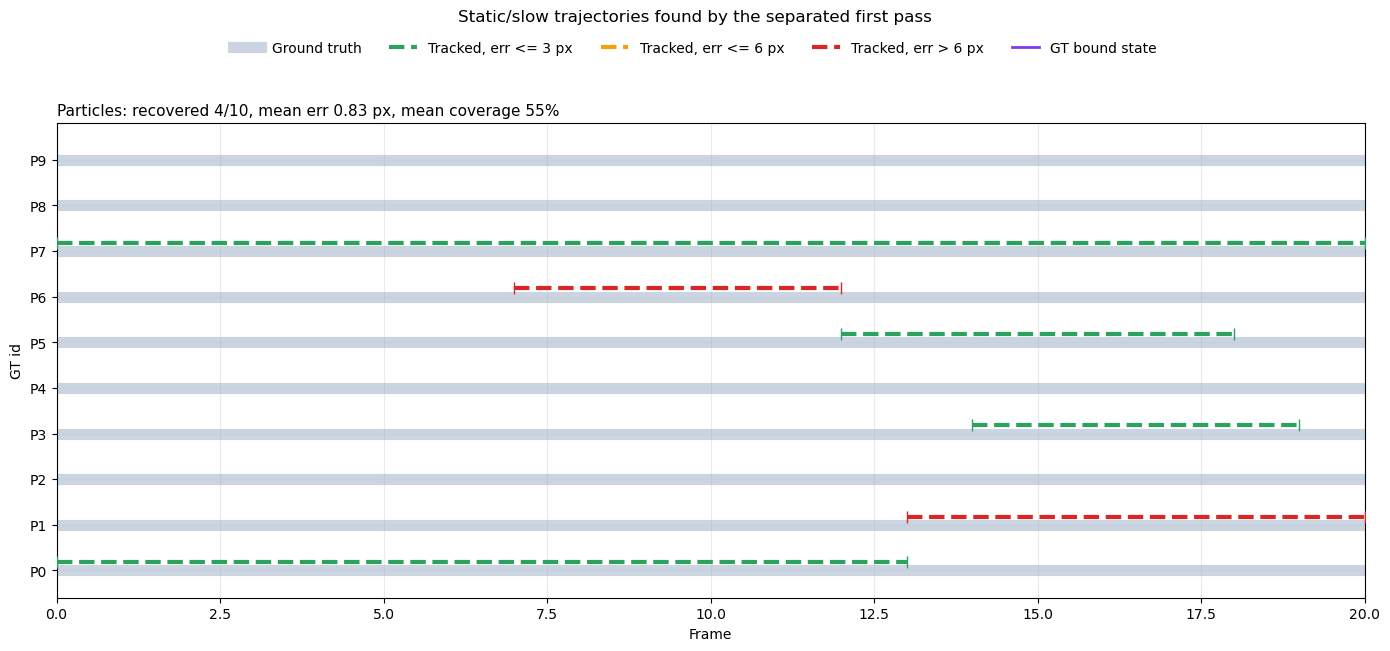

In [32]:
loc_results_static = sim.track(
    **STATIC_TRACKING_KWARGS,
    cost_func_peak2peak=peak2peak_cost,
    cost_func_traj2traj=traj_cost,
)

static_trajs_loc_sep = loc_results_static[0]

print(f"Separated static pass found {len(static_trajs_loc_sep)} static/slow trajectories.")
show_trajectories(
    frames_sep,
    static_trajs_loc_sep,
    frame_id=simulation_config["nframes"] - 1,
    show_id=True,
)

linear_trajectories_visualizer(
    static_trajs_loc_sep,
    trajs_GT_sep,
    title="Static/slow trajectories found by the separated first pass",
)


In [33]:
peaks_for_tracking_sep = extract_peaks(
    frames_sep,
    **PEAK_EXTRACTION_KWARGS,
)

mobile_peaks_for_tracking_sep, removed_static_peaks = remove_static_peaks(
    peaks_for_tracking_sep,
    static_trajs_loc_sep,
    tolerance=REMOVE_STATIC_TOLERANCE,
    return_removed=True,
    verbose=True,
)

def count_peaks_by_frame(peaks):
    return np.array([len(frame_peaks) for frame_peaks in peaks], dtype=int)

peak_count_summary = pd.DataFrame({
    "frame": np.arange(len(peaks_for_tracking_sep)),
    "all_peaks": count_peaks_by_frame(peaks_for_tracking_sep),
    "mobile_peaks_after_static_removal": count_peaks_by_frame(mobile_peaks_for_tracking_sep),
})
peak_count_summary["removed_static_peaks"] = (
    peak_count_summary["all_peaks"]
    - peak_count_summary["mobile_peaks_after_static_removal"]
)

display(peak_count_summary)
print(f"Removed {len(removed_static_peaks)} static-associated detections in total.")


Removed 13 peaks from static trajectory 0 (length 13, frames 0–12)
Removed 20 peaks from static trajectory 7 (length 20, frames 0–19)
Removed 5 peaks from static trajectory 6 (length 5, frames 7–11)
Removed 6 peaks from static trajectory 5 (length 6, frames 12–17)
Removed 7 peaks from static trajectory 1 (length 7, frames 13–19)
Removed 5 peaks from static trajectory 3 (length 5, frames 14–18)


,frame,all_peaks,mobile_peaks_after_static_removal,removed_static_peaks
0,0,14,12,2
1,1,11,9,2
2,2,13,11,2
3,3,13,11,2
4,4,13,11,2
5,5,13,11,2
6,6,11,9,2
7,7,13,10,3
8,8,13,10,3
9,9,12,9,3


Removed 56 static-associated detections in total.


In [34]:
animate_video_with_peaks(
    frames_sep,
    mobile_peaks_for_tracking_sep,
    interval=100,
    vmin=0,
    vmax=1000,
)


Tracking 187 peaks across 20 frames...
Found 12 mobile trajectories
Separated mobile pass found 12 mobile trajectories.


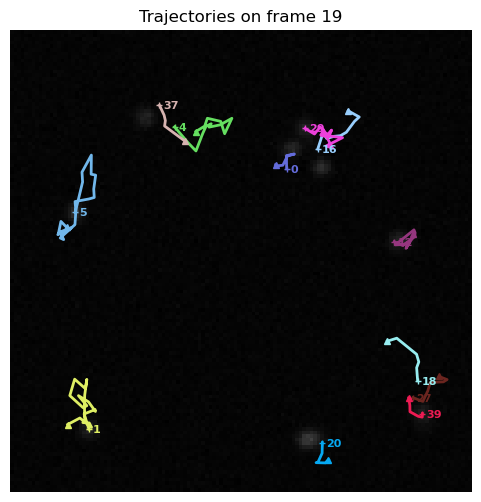

In [35]:
mobile_trajs_loc_sep, cost_peak2peak_mobile_sep, _, _ = track_from_peaks(
    mobile_peaks_for_tracking_sep,
    trajectories_GT=None,
    **MOBILE_TRACKING_KWARGS,
)

print(f"Separated mobile pass found {len(mobile_trajs_loc_sep)} mobile trajectories.")
show_trajectories(
    frames_sep,
    mobile_trajs_loc_sep,
    frame_id=simulation_config["nframes"] - 1,
    show_id=True,
)


Computing assignment using algorithm: hungarian
0 -> -1
1 -> 4
2 -> 6
3 -> 8
4 -> 5
5 -> -1
6 -> -1
7 -> 2
8 -> -1
9 -> 1
10 -> -1
11 -> 9
12 -> 0
13 -> 7
14 -> -1
15 -> -1
16 -> -1
17 -> 3
Trajectory ID: -1, Frames: 0->6, Number of positions: 7, Relabelled: No
Trajectory ID: 4, Frames: 0->19, Number of positions: 20, Relabelled: Yes
Trajectory ID: 6, Frames: 0->13, Number of positions: 14, Relabelled: Yes
Trajectory ID: 8, Frames: 0->19, Number of positions: 20, Relabelled: Yes
Trajectory ID: 5, Frames: 1->12, Number of positions: 12, Relabelled: Yes
Trajectory ID: -1, Frames: 2->10, Number of positions: 9, Relabelled: No
Trajectory ID: -1, Frames: 3->8, Number of positions: 6, Relabelled: No
Trajectory ID: 2, Frames: 4->9, Number of positions: 6, Relabelled: Yes
Trajectory ID: -1, Frames: 8->14, Number of positions: 7, Relabelled: No
Trajectory ID: 1, Frames: 9->19, Number of positions: 11, Relabelled: Yes
Trajectory ID: -1, Frames: 12->16, Number of positions: 5, Relabelled: No
Traj

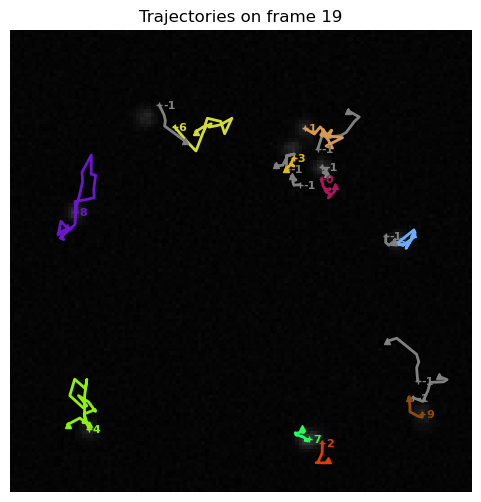

In [36]:
combined_trajs_loc_sep = mobile_trajs_loc_sep + copy.deepcopy(static_trajs_loc_sep)

trajs_loc_sep, cost_traj2traj_sep, assignment_output_sep = assign_trajectories(
    combined_trajs_loc_sep,
    trajs_GT_sep,
    algorithm="hungarian",
    cost_function=traj_cost,
    verbose=True,
)

print(f"Separated combined pipeline kept {len(trajs_loc_sep)} trajectories after final assignment.")
show_trajectories(
    frames_sep,
    trajs_loc_sep,
    frame_id=simulation_config["nframes"] - 1,
    show_id=True,
)


## 3. Compare regular and separated pipelines

The visualizer aligns reconstructed trajectories to the GT lifetime rows. The small table gives a compact metric check before looking at the trajectory timeline plots.


In [37]:
def summarize_tracking_result(label, trajectories, trajectories_gt):
    hota = hota_only(trajectories, trajectories_gt)
    cov_frag = coverage_and_fragments(trajectories, trajectories_gt)
    coverage = cov_frag["coverage"]
    fragments = cov_frag["fragments"]

    return {
        "method": label,
        "n_tracks": len(trajectories),
        "HOTA": hota["hota"],
        "DetA": hota["deta"],
        "AssA": hota["assa"],
        "mean_GT_coverage": np.nanmean(coverage) if len(coverage) else np.nan,
        "mean_fragments_per_GT": np.nanmean(fragments) if len(fragments) else np.nan,
    }

separation_summary = pd.DataFrame([
    summarize_tracking_result("regular", trajs_loc_reg, trajs_GT_reg),
    summarize_tracking_result("separated", trajs_loc_sep, trajs_GT_sep),
])

display(separation_summary.round(3))


,method,n_tracks,HOTA,DetA,AssA,mean_GT_coverage,mean_fragments_per_GT
0,regular,16,0.749,0.726,0.772,0.715,1.0
1,separated,18,0.699,0.715,0.683,0.635,1.0


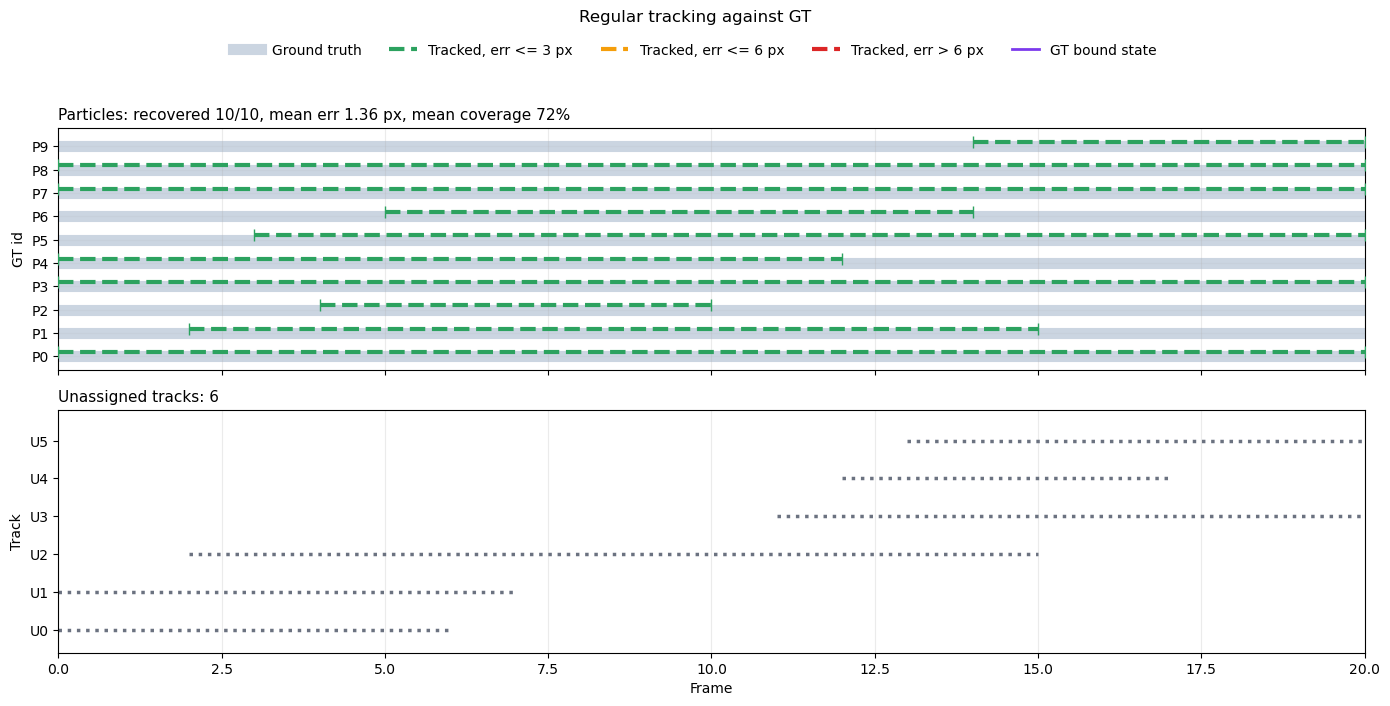

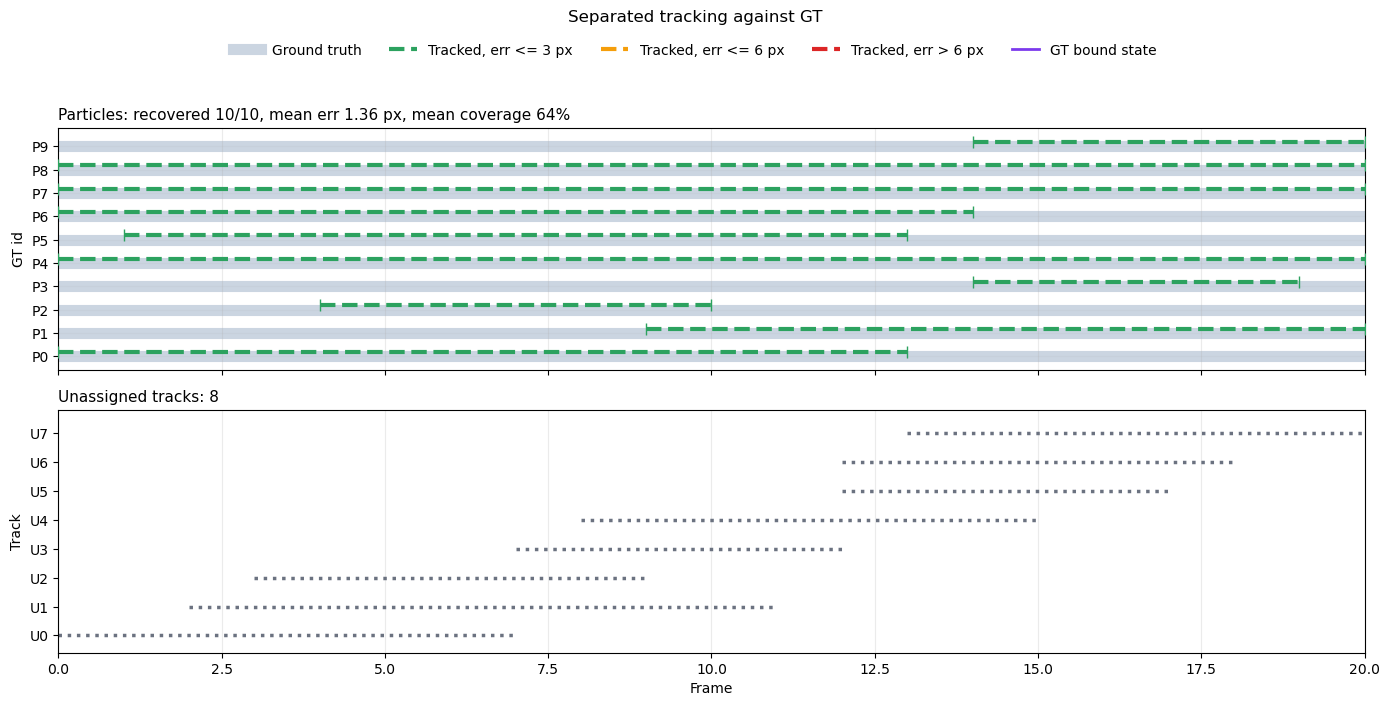

In [38]:
linear_trajectories_visualizer(
    trajs_loc_reg,
    trajs_GT_reg,
    title="Regular tracking against GT",
)

linear_trajectories_visualizer(
    trajs_loc_sep,
    trajs_GT_sep,
    title="Separated tracking against GT",
)


## Appendix: exploratory branch preserved for reference

The notebook originally started with a separate exploratory simulation before the regular-vs-separated comparison. That made the later comparison inconsistent because the separated branch reused variables from the exploratory simulation while the regular branch used the seeded comparison simulation.

The information from that branch is preserved here, but it is intentionally non-executed.

```python
# Exploratory simulation used at the top of the previous notebook.
D_list = [
    (0.02, 0.20),
    (0.10, 0.30),
    (2.50, 0.15),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 12,
    "nframes": 20,
    "nposframe": 10,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 650,
    "intensity_std": 300,
    "sigma_mean": 1.5,
    "sigma_std": 0.5,
}

image_config = {
    "particle_intensity": [650, 300],
    "background_intensity": [150, 50],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
    "use_trajectory_sigma": True,
}

# Exploratory static-only tracking settings.
localization_results = sim.track(
    mode="localization",
    detection_threshold=None,
    max_distance=2,
    min_length=10,
    max_gap=2,
    stitch_fragments=True,
    stitch_max_gap=4,
    stitch_base_distance=3.0,
    verbose_stitching=True,
)

static_trajectories_localization = localization_results[0]
print(f"{len(static_trajectories_localization)} particles were identified as static.")
show_trajectories(frames, static_trajectories_localization, frame_id=simulation_config["nframes"] - 1, show_id=True)
linear_trajectories_visualizer(static_trajectories_localization, trajectories_GT)
```

The old notebook also tried the idea of physically hiding static particles in the video. That was not kept as the main method because removing static detections from the peak list is simpler and avoids modifying image data.

```python
# Artificially remove static particles from the video by replacing them with background noise.
# frames_aniso_mobile = hide_trajectories(
#     frames,
#     static_trajectories_localization,
#     bg_mean=image_props["background_intensity"][0],
#     bg_std=image_props["background_intensity"][1],
# )
# animate_video(frames_aniso_mobile, interval=100)
```

The manual static-peak removal loop was replaced by the helper `remove_static_peaks(...)`, but the logic is the same: for every static trajectory position, remove the closest localized peak in the same frame if it is within a tolerance.

```python
mobile_peaks_for_tracking = copy.deepcopy(peaks_for_tracking)

for traj in static_trajectories_localization:
    removed_count = 0
    for frame_id, traj_pos in zip(traj.frames(), traj.positions):
        peak_list = mobile_peaks_for_tracking[frame_id]
        closest_peak_idx = None
        closest_peak_dist = float("inf")

        for idx, peak in enumerate(peak_list):
            peak_pos = peak[0]
            dist = np.linalg.norm(np.array(peak_pos) - np.array(traj_pos))
            if dist < closest_peak_dist:
                closest_peak_dist = dist
                closest_peak_idx = idx

        if closest_peak_dist < 5.0:
            peak_list.pop(closest_peak_idx)
            removed_count += 1

    print(f"Removed {removed_count} peaks from static trajectory {traj.id}")
```
